# Week 3: Cross-Cultural Market Basket Analysis

**Research question (option 01, Event):** Does the same item pair behave differently during Ramadan than in baseline (non-event) transactions?

**Scope**
- Only Istanbul (`TR_Istanbul`) and Dubai (`AE_Dubai`), the two markets where Ramadan occurs.
- Both groups come from the same markets, so a difference is less likely to be a city effect.
- Eid baskets are excluded from both groups.

**Contexts**
- **A (Ramadan):** `Cultural_Event == "Ramadan"`
- **B (Baseline):** `Cultural_Event == "None"`

## 0. Setup

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

SEED = 42  # Apriori is deterministic, but the README should state the seed
DATA_PATH = "Cross Cultural Market Basket Dataset v2.xlsx"

## 1. Load data
- `keep_default_na=False` keeps `"None"` as a real category instead of NaN.
- Only the `Transactions` sheet is used (not `Instructor Notes`).

In [27]:
df = pd.read_excel(DATA_PATH, sheet_name="Transactions", keep_default_na=False)
print(df.shape)
df.head()

(900, 42)


,Transaction_ID,Market_ID,Country,Primary_Language,Region_Type,Urban_Density,Age_Group,Household_Type,Meal_Occasion,Social_Setting,...,Fruit,Dessert,Soft_Drink,Mineral_Water,Sandwich,Dumplings,Curry_Sauce,Pasta,Cheese,Soup
0,TX00001,KR_Seoul,South Korea,Korean,Suburban,Medium,35-49,Family,Dinner,Family,...,0,1,1,1,0,1,0,1,0,0
1,TX00002,KR_Seoul,South Korea,Korean,Metropolitan Core,Medium,35-49,Couple,Dinner,Couple,...,0,0,0,0,0,0,0,0,0,0
2,TX00003,KR_Seoul,South Korea,Korean,Metropolitan Core,High,25-34,Couple,Lunch,Group,...,0,0,0,0,0,0,0,0,0,0
3,TX00004,KR_Seoul,South Korea,Korean,Metropolitan Core,High,18-24,Single,Lunch,Solo,...,1,0,0,0,0,0,0,0,0,0
4,TX00005,KR_Seoul,South Korea,Korean,Metropolitan Core,High,25-34,Family,Lunch,Solo,...,0,1,0,0,0,0,0,0,0,0


In [28]:
# The 22 product columns run from 'Coffee' to 'Soup'
PRODUCTS = list(df.loc[:, "Coffee":"Soup"].columns)
print(len(PRODUCTS), PRODUCTS)

22 ['Coffee', 'Tea', 'Milk', 'Dates', 'Bread', 'Butter', 'Rice', 'Kimchi', 'Instant_Noodles', 'Eggs', 'Chicken', 'Yogurt', 'Fruit', 'Dessert', 'Soft_Drink', 'Mineral_Water', 'Sandwich', 'Dumplings', 'Curry_Sauce', 'Pasta', 'Cheese', 'Soup']


## 2. Explore the contexts
Check group sizes before choosing a research question. Small groups (N below about 50) give unstable lift.

In [29]:
CONTEXT_COLS = ["Cultural_Event", "Social_Setting", "Meal_Occasion",
                "Shopping_Channel", "Promotion_Exposure"]

for col in CONTEXT_COLS:
    print(f"--- {col} ---")
    print(df[col].value_counts(), "\n")

--- Cultural_Event ---
Cultural_Event
None              483
Ramadan            99
Eid                69
Chuseok            37
Holi               37
New Year           32
Christmas          31
Hanami             30
Bastille Day       30
Diwali             27
Lunar New Year     25
Name: count, dtype: int64 

--- Social_Setting ---
Social_Setting
Solo      346
Family    217
Couple    215
Group     122
Name: count, dtype: int64 

--- Meal_Occasion ---
Meal_Occasion
Dinner        256
Lunch         221
Breakfast     181
Afternoon     144
Late Night     98
Name: count, dtype: int64 

--- Shopping_Channel ---
Shopping_Channel
Supermarket          298
E-commerce           204
Local Market         165
Convenience Store    130
Food Delivery        103
Name: count, dtype: int64 

--- Promotion_Exposure ---
Promotion_Exposure
None              483
Coupon            162
Bundle            150
Loyalty Reward    105
Name: count, dtype: int64 



In [30]:
# Overall popularity of each item (= single-item support)
df[PRODUCTS].mean().sort_values(ascending=False)

Rice               0.398889
Mineral_Water      0.307778
Bread              0.295556
Chicken            0.277778
Tea                0.263333
Soft_Drink         0.247778
Coffee             0.228889
Milk               0.187778
Dessert            0.183333
Fruit              0.153333
Sandwich           0.142222
Eggs               0.141111
Instant_Noodles    0.128889
Butter             0.115556
Cheese             0.113333
Pasta              0.112222
Soup               0.110000
Curry_Sauce        0.093333
Yogurt             0.088889
Dates              0.086667
Dumplings          0.075556
Kimchi             0.064444
dtype: float64

## 3. Filter two groups
1. Keep only the two markets.
2. Split by `Cultural_Event`.

In [31]:
MARKETS = ["TR_Istanbul", "AE_Dubai"]

markets_df = df[df["Market_ID"].isin(MARKETS)]

group_a = markets_df[markets_df["Cultural_Event"] == "Ramadan"]  # Context A
group_b = markets_df[markets_df["Cultural_Event"] == "None"]     # Context B (baseline)

print(f"Markets subset: N = {len(markets_df)}")
print(f"Ramadan:        N = {len(group_a)}")
print(f"Baseline:       N = {len(group_b)}")

Markets subset: N = 300
Ramadan:        N = 99
Baseline:       N = 132


## 4. One-hot matrix
The product columns are already 0/1, so no TransactionEncoder is needed. We select them and cast to `bool`.

In [32]:
basket_a = group_a[PRODUCTS].astype(bool)
basket_b = group_b[PRODUCTS].astype(bool)

print(basket_a.shape, basket_b.shape)

# Sanity check: item frequency (single-item support) side by side
item_support = pd.DataFrame({
    "Ramadan": basket_a.mean(),
    "Baseline": basket_b.mean(),
}).sort_values("Ramadan", ascending=False)
item_support.round(3)

(99, 22) (132, 22)


,Ramadan,Baseline
Mineral_Water,0.556,0.394
Milk,0.485,0.129
Dates,0.434,0.068
Rice,0.293,0.242
Tea,0.283,0.341
Coffee,0.253,0.182
Bread,0.253,0.326
Chicken,0.242,0.280
Soft_Drink,0.222,0.242
Fruit,0.202,0.098


## 5. Apriori (same thresholds for both groups)
**`MIN_SUPPORT = 0.05`**, about 5 baskets in the Ramadan group and 7 in the baseline.
- 0.03 gives over a thousand noisy rules built on 3 to 4 baskets.
- 0.10 leaves only 9 rules in the baseline and drops Dates (support 0.068 there).

**`MIN_CONFIDENCE = 0.3`** keeps rules where B appears in at least 30 % of the baskets that contain A.

Both groups are mined with the same function, so the thresholds are identical.

In [33]:
MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.3

def mine_rules(basket):
    itemsets = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True)
    rules = association_rules(itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE)
    return rules.sort_values("lift", ascending=False)

rules_a = mine_rules(basket_a)   # Ramadan
rules_b = mine_rules(basket_b)   # Baseline

print(f"Ramadan:  {len(rules_a)} rules")
print(f"Baseline: {len(rules_b)} rules")

Ramadan:  359 rules
Baseline: 39 rules


In [34]:
# Top rules: Ramadan
rules_a[["antecedents", "consequents", "support", "confidence", "lift"]].head(10).round(3)

,antecedents,consequents,support,confidence,lift
287,"frozenset({Rice, Milk})","frozenset({Dates, Chicken})",0.051,0.312,5.156
283,"frozenset({Dates, Chicken})","frozenset({Rice, Milk})",0.051,0.833,5.156
352,"frozenset({Dates, Bread})","frozenset({Mineral_Water, Rice, Milk})",0.051,0.417,4.583
351,"frozenset({Mineral_Water, Rice, Milk})","frozenset({Dates, Bread})",0.051,0.556,4.583
350,"frozenset({Bread, Mineral_Water, Milk})","frozenset({Dates, Rice})",0.051,0.556,3.929
353,"frozenset({Dates, Rice})","frozenset({Bread, Mineral_Water, Milk})",0.051,0.357,3.929
333,"frozenset({Dates, Soft_Drink})","frozenset({Mineral_Water, Sandwich})",0.051,0.385,3.808
337,"frozenset({Mineral_Water, Sandwich})","frozenset({Dates, Soft_Drink})",0.051,0.500,3.808
347,"frozenset({Dates, Mineral_Water, Rice})","frozenset({Bread, Milk})",0.051,0.455,3.750
355,"frozenset({Bread, Milk})","frozenset({Dates, Mineral_Water, Rice})",0.051,0.417,3.750


In [35]:
# Top rules: Baseline
rules_b[["antecedents", "consequents", "support", "confidence", "lift"]].head(10).round(3)

,antecedents,consequents,support,confidence,lift
33,"frozenset({Bread, Cheese})",frozenset({Tea}),0.053,0.875,2.567
32,"frozenset({Bread, Tea})",frozenset({Cheese}),0.053,0.368,2.432
35,frozenset({Cheese}),"frozenset({Bread, Tea})",0.053,0.350,2.432
34,"frozenset({Cheese, Tea})",frozenset({Bread}),0.053,0.778,2.388
38,"frozenset({Mineral_Water, Rice})",frozenset({Chicken}),0.053,0.583,2.081
29,"frozenset({Bread, Tea})",frozenset({Coffee}),0.053,0.368,2.026
1,frozenset({Coffee}),frozenset({Tea}),0.121,0.667,1.956
0,frozenset({Tea}),frozenset({Coffee}),0.121,0.356,1.956
30,"frozenset({Bread, Coffee})",frozenset({Tea}),0.053,0.636,1.867
19,frozenset({Rice}),frozenset({Chicken}),0.114,0.469,1.672


In [36]:
# Simple rules (one item on each side), sorted by support
def simple_rules(rules):
    mask = (rules["antecedents"].apply(len) == 1) & (rules["consequents"].apply(len) == 1)
    return rules[mask].sort_values("support", ascending=False)

cols = ["antecedents", "consequents", "support", "confidence", "lift"]
simple_rules(rules_a)[cols].head(8).round(3)

,antecedents,consequents,support,confidence,lift
40,frozenset({Dates}),frozenset({Mineral_Water}),0.343,0.791,1.423
41,frozenset({Mineral_Water}),frozenset({Dates}),0.343,0.618,1.423
19,frozenset({Dates}),frozenset({Milk}),0.323,0.744,1.535
20,frozenset({Milk}),frozenset({Dates}),0.323,0.667,1.535
29,frozenset({Milk}),frozenset({Mineral_Water}),0.293,0.604,1.088
28,frozenset({Mineral_Water}),frozenset({Milk}),0.293,0.527,1.088
7,frozenset({Coffee}),frozenset({Mineral_Water}),0.162,0.640,1.152
23,frozenset({Rice}),frozenset({Milk}),0.162,0.552,1.138


In [37]:
simple_rules(rules_b)[cols].head(8).round(3)

,antecedents,consequents,support,confidence,lift
6,frozenset({Bread}),frozenset({Tea}),0.144,0.442,1.296
7,frozenset({Tea}),frozenset({Bread}),0.144,0.422,1.296
24,frozenset({Mineral_Water}),frozenset({Chicken}),0.136,0.346,1.235
23,frozenset({Chicken}),frozenset({Mineral_Water}),0.136,0.486,1.235
0,frozenset({Tea}),frozenset({Coffee}),0.121,0.356,1.956
1,frozenset({Coffee}),frozenset({Tea}),0.121,0.667,1.956
18,frozenset({Chicken}),frozenset({Rice}),0.114,0.405,1.672
19,frozenset({Rice}),frozenset({Chicken}),0.114,0.469,1.672


### Chosen rule: Dates → Milk
- **Simple:** one item on each side.
- **Well supported:** 32 of 99 Ramadan baskets (support 0.323). The top-lift rules rest on only 5 baskets.
- **Meaningful:** listed as a Ramadan example in the workbook's Data Dictionary.

The rule does not appear in the baseline rules because Dates is below `MIN_SUPPORT` there. The measures are therefore computed manually for both groups.

## 6. Compare one rule A → B

In [38]:
ANTECEDENT = "Dates"
CONSEQUENT = "Milk"

def rule_measures(basket, a, b):
    n = len(basket)
    p_a = basket[a].mean()
    p_b = basket[b].mean()
    support = (basket[a] & basket[b]).mean()
    confidence = support / p_a if p_a > 0 else float("nan")
    lift = confidence / p_b if p_b > 0 else float("nan")
    return {"N": n,
            f"N with {a}": int(basket[a].sum()),
            f"N with {a} & {b}": int((basket[a] & basket[b]).sum()),
            "Support": support, "Confidence": confidence, "Lift": lift}

comparison = pd.DataFrame({
    "Ramadan": rule_measures(basket_a, ANTECEDENT, CONSEQUENT),
    "Baseline": rule_measures(basket_b, ANTECEDENT, CONSEQUENT),
}).T.astype(float)
comparison.loc["Δ (Ramadan minus Baseline)"] = comparison.loc["Ramadan"] - comparison.loc["Baseline"]
comparison.loc["Δ (Ramadan minus Baseline)", comparison.columns[:3]] = float("nan")
comparison.index.name = f"Context ({ANTECEDENT} → {CONSEQUENT})"

comparison.round(4).astype({c: "Int64" for c in comparison.columns[:3]}).to_csv("rule_comparison.csv")
comparison.round(3)

,N,N with Dates,N with Dates & Milk,Support,Confidence,Lift
Context (Dates → Milk),,,,,,
Ramadan,99.0,43.0,32.0,0.323,0.744,1.535
Baseline,132.0,9.0,0.0,0.000,0.000,0.000
Δ (Ramadan minus Baseline),NaN,NaN,NaN,0.323,0.744,1.535


In [39]:
# Sanity check: the manual numbers should match mlxtend for the Ramadan group
rules_a[(rules_a["antecedents"] == frozenset({ANTECEDENT})) &
        (rules_a["consequents"] == frozenset({CONSEQUENT}))][cols].round(3)

,antecedents,consequents,support,confidence,lift
19,frozenset({Dates}),frozenset({Milk}),0.323,0.744,1.535


## 7. Visualization
Blue is Ramadan and orange is Baseline in both charts.

**7a. Number of rules per confidence threshold.** Itemsets are mined with the same `MIN_SUPPORT`, then the confidence filter is varied.

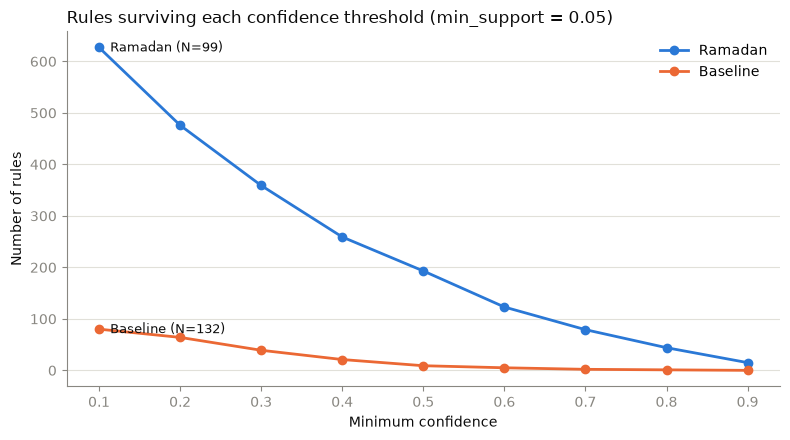

,Ramadan,Baseline
0.1,627,80
0.2,476,64
0.3,359,39
0.4,259,21
0.5,193,9
0.6,123,5
0.7,79,2
0.8,44,1
0.9,15,0


In [40]:
COLORS = {"Ramadan": "#2a78d6", "Baseline": "#eb6834"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

def style_axes(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

thresholds = [round(t, 1) for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]]

def rules_per_threshold(basket):
    itemsets = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True)
    all_rules = association_rules(itemsets, metric="confidence", min_threshold=0.0)
    return [(all_rules["confidence"] >= t).sum() for t in thresholds]

counts = pd.DataFrame({
    "Ramadan": rules_per_threshold(basket_a),
    "Baseline": rules_per_threshold(basket_b),
}, index=thresholds)

fig, ax = plt.subplots(figsize=(8, 4.5))
for name, color in COLORS.items():
    ax.plot(counts.index, counts[name], color=color, linewidth=2, marker="o", markersize=6, label=name)
    ax.annotate(f"{name} (N={len(basket_a) if name == 'Ramadan' else len(basket_b)})",
                xy=(counts.index[0], counts[name].iloc[0]), xytext=(8, 0),
                textcoords="offset points", color=INK, va="center", fontsize=9)
style_axes(ax)
ax.set_xlabel("Minimum confidence", color=INK)
ax.set_ylabel("Number of rules", color=INK)
ax.set_title(f"Rules surviving each confidence threshold (min_support = {MIN_SUPPORT})",
             color=INK, loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig_rules_per_confidence.png", dpi=150)
plt.show()

counts

**7b. Dates → Milk in both contexts.** Support and confidence are shares between 0 and 1. Lift uses another scale, so it has its own panel. The dashed line at 1 means no association.

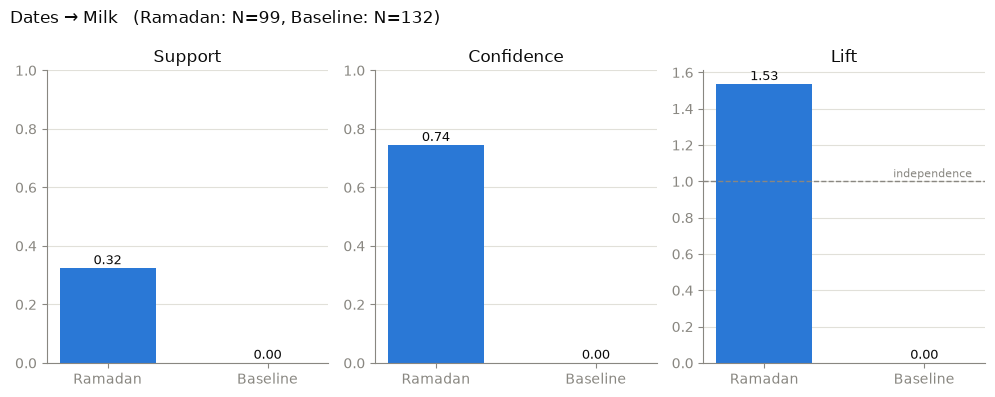

In [41]:
rule_rows = comparison.loc[["Ramadan", "Baseline"]]
metrics = ["Support", "Confidence", "Lift"]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, metric in zip(axes, metrics):
    values = rule_rows[metric]
    bars = ax.bar(values.index, values.values,
                  color=[COLORS[c] for c in values.index], width=0.6)
    for bar, v in zip(bars, values.values):
        ax.annotate(f"{v:.2f}", xy=(bar.get_x() + bar.get_width() / 2, v),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", color=INK, fontsize=9)
    if metric == "Lift":
        ax.axhline(1, color=MUTED, linestyle="--", linewidth=1)
        ax.annotate("independence", xy=(1.3, 1), xytext=(0, 3), textcoords="offset points",
                    color=MUTED, fontsize=8, ha="right")
    else:
        ax.set_ylim(0, 1)
    style_axes(ax)
    ax.set_title(metric, color=INK)

n_labels = ", ".join(f"{c}: N={int(rule_rows.loc[c, 'N'])}" for c in rule_rows.index)
fig.suptitle(f"{ANTECEDENT} → {CONSEQUENT}   ({n_labels})", color=INK, x=0.01, ha="left")
plt.tight_layout()
plt.savefig("fig_rule_comparison.png", dpi=150)
plt.show()

### Checks for alternative explanations
Do the groups differ in other ways than Ramadan? We compare:
- basket size and value
- promotion exposure
- shopping channel
- market mix, and whether the rule holds in each market on its own

In [42]:
compare_df = pd.concat([group_a.assign(Context="Ramadan"), group_b.assign(Context="Baseline")])

print("Average basket size and value")
print(compare_df.groupby("Context")[["Basket_Size", "Basket_Value_USD"]].mean().round(2), "\n")

for col in ["Promotion_Exposure", "Shopping_Channel", "Market_ID"]:
    print(f"Share of baskets by {col}")
    print(pd.crosstab(compare_df[col], compare_df["Context"], normalize="columns").round(2), "\n")

# Does Dates -> Milk hold within each market?
per_market = compare_df.groupby(["Context", "Market_ID"]).apply(
    lambda g: pd.Series({
        "N": len(g),
        f"N with {ANTECEDENT}": int(g[ANTECEDENT].sum()),
        f"N with {ANTECEDENT} & {CONSEQUENT}": int((g[ANTECEDENT] & g[CONSEQUENT]).sum()),
    }), include_groups=False)
per_market["Confidence"] = (per_market.iloc[:, 2] / per_market.iloc[:, 1]).round(2)
per_market

Average basket size and value
          Basket_Size  Basket_Value_USD
Context                                
Baseline         3.53             13.10
Ramadan          4.36             17.51 

Share of baskets by Promotion_Exposure
Context             Baseline  Ramadan
Promotion_Exposure                   
Bundle                  0.16     0.15
Coupon                  0.17     0.12
Loyalty Reward          0.14     0.13
None                    0.53     0.60 

Share of baskets by Shopping_Channel
Context           Baseline  Ramadan
Shopping_Channel                   
E-commerce            0.27     0.24
Food Delivery         0.17     0.21
Local Market          0.25     0.18
Supermarket           0.31     0.36 

Share of baskets by Market_ID
Context      Baseline  Ramadan
Market_ID                     
AE_Dubai          0.4     0.68
TR_Istanbul       0.6     0.32 



N  N with Dates  N with Dates & Milk  Confidence
Context  Market_ID                                                     
Baseline AE_Dubai     53             7                    0        0.00
         TR_Istanbul  79             2                    0        0.00
Ramadan  AE_Dubai     67            31                   23        0.74
         TR_Istanbul  32            12                    9        0.75

## 8. Interpretation

**Observed difference**  
Dates → Milk is much stronger during Ramadan.

| | N | Baskets with Dates | … also with Milk | Confidence | Lift |
|---|---|---|---|---|---|
| Ramadan | 99 | 43 | 32 | 0.74 | 1.53 |
| Baseline | 132 | 9 | 0 | 0 | 0 |

The two items are bought together almost only during Ramadan.

**Sample size and stability**
- The Ramadan result rests on 43 baskets with dates, which is reasonable.
- The baseline result rests on only 9, so "never together" is a signal, not proof.
- The Ramadan group has far more rules at every confidence threshold (figure 7a), even though it is the smaller group.

**Why lift is only 1.53**  
Milk is common during Ramadan (48 % of baskets vs 13 % in baseline). Lift divides by P(Milk), so a popular item on the right side keeps lift moderate even when confidence is high.

**Alternative explanations**
- **Market mix:** Dubai is 68 % of Ramadan baskets but 40 % of baseline baskets. The rule holds in each market on its own (confidence about 0.75 in both cities during Ramadan, 0 in baseline), so this does not explain it.
- **Basket size:** Ramadan baskets are larger (4.4 vs 3.5 items). Larger baskets make any pair more likely, which may explain part of the higher rule count.
- **Promotion:** Ramadan baskets see *fewer* promotions (60 % with none vs 53 %), so promotions are an unlikely cause.
- **Channel:** The channel mix is similar in both groups.
- **Availability and price:** Dates may be easier to find or cheaper during Ramadan. The data cannot separate demand from supply.

**Conclusion**  
The data support the *hypothesis* that Ramadan is linked to buying dates and milk together. This is an association in synthetic data. It does not prove that religion or culture causes the behaviour.

## 9. BI action

**Action:** Dates + Milk placement and recommendation during Ramadan in Istanbul and Dubai.
- In stores, place milk next to dates.
- Online, suggest milk when dates are added to the basket.
- Run it in some stores and sessions and keep the rest as a control group. The rule is an association, so the effect must be tested.

**KPI:** Average basket value (USD) of Ramadan baskets that contain dates, test group vs control group. Today, Ramadan baskets in these markets average USD 17.51.

**Guardrail:** The milk stock-out rate in test stores must not rise above the control stores. Empty milk shelves would hurt customers who only come for milk.

## 10. Limitations and data source

**Data source:** `Cross Cultural Market Basket Dataset v2.xlsx`, sheet `Transactions`. It contains 900 synthetic transactions provided by the instructor (generation seed 20260916). The `Instructor Notes` sheet was not used.

**Limitations**
- **Synthetic data:** The patterns were planted by the generator. The results show that the method works, not how real shoppers behave.
- **Small baseline:** Only 9 baseline baskets contain dates, so the baseline measures are unstable.
- **Narrow scope:** Only two markets and one event. Eid baskets (N = 69) were left out, so the results may not hold for other events or markets.
- **No significance test:** The differences are descriptive. A test such as Fisher's exact test would be needed to measure uncertainty.
- **Threshold choice:** The rule counts depend on `MIN_SUPPORT` and `MIN_CONFIDENCE`. The measures for Dates → Milk are computed directly and do not depend on them.
- **No causal claim:** Context variables describe observable conditions. They do not show that culture or religion causes the pattern.